2 alef test :['اندرآور', 'باخوش', 'زجمشید', 'رستم', 'بدجا']
+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|word    |embedding                                                                                                                                                                                                           |
+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|رستم    |[0.7447191472175341, 0.450907034861292, 0.12812514294081345, -0.5076334344289668, -0.06455780225210894, -0.7543252439107251, -0.5943430543611025, 0.5864609100964526, -0.05336777210945021, 0.2115700544655903]     |
|سهراب   |[0.43818755116741626, -0.119892189

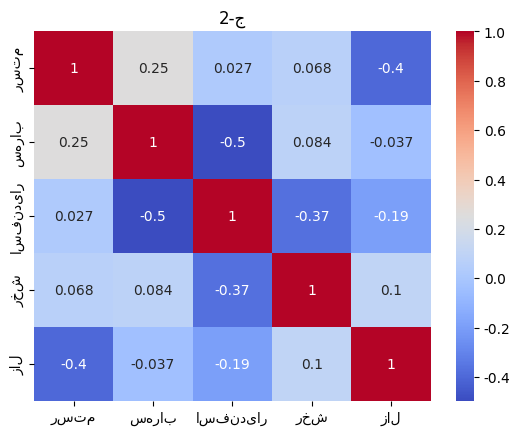

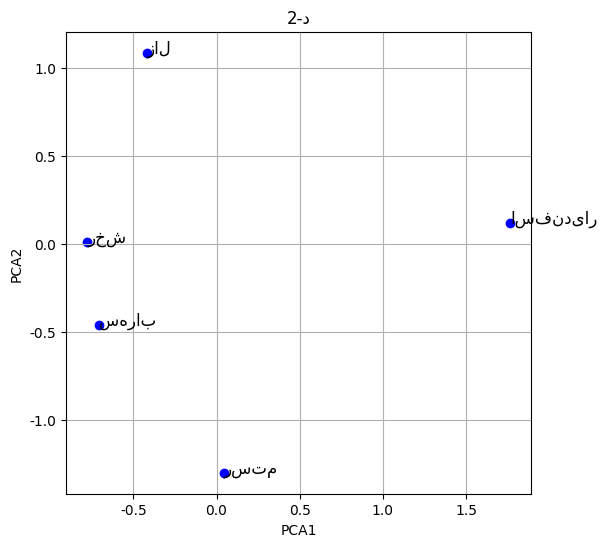

Total time: 16.936543941497803 seconds


In [43]:
#2-الف
import sys
from operator import add
from pyspark.sql import SparkSession
import time
import re
from pyspark.ml.feature import Tokenizer, RegexTokenizer, PCA
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import col, udf
from pyspark.sql.types import IntegerType, FloatType, ArrayType, StructType, StructField, StringType
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

startTime = time.time()

if __name__ == "__main__":

    spark = SparkSession\
        .builder\
        .appName("PythonWordCountWithParallelize")\
        .getOrCreate()

    stop_words = [
        "آیا", "از", "به", "برای", "تا", "در", "که", "این", "آن", "بر", "با", "اگر", "چرا", "چگونه",
        "همه", "هم", "یا", "هر", "خود", "دست", "اینکه", "بود", "می", "نیز", "میتوان", "چه", "کجا",
        "چند", "روی", "او", "من", "تو", "ما", "شما", "آنها", "که", "و", "ی", "می‌کند", "که",
        "برای", "نه", "بهتر", "اگرچه","را", 'ز', "هرچند", "ولی", "اما", "درحالی", "فقط", "هنوز", "اینکه"
    ]

    punctuation = r'[.,!?;:"(){}\[\]«»٫،؛؟]'

    path = 'shahname.txt'
    with open(path, 'r', encoding='utf-8') as file:
        lines = file.readlines()

    rdd = spark.sparkContext.parallelize(lines)

    def clean_line(line):
        line = re.sub(punctuation, '', line)
        words = line.split()
        words = [word for word in words if word not in stop_words]
        return ' '.join(words)

    final_lines = rdd.filter(lambda line: not line.strip().startswith('#') and line.strip() != "")
    cleaned_lines = final_lines.map(clean_line)

    output_path = 'output.txt'
    with open(output_path, 'w', encoding='utf-8') as f:
        for line in cleaned_lines.collect():
            if line.strip():
                f.write(line + '\n')
    cleaned_lines_df = spark.createDataFrame(cleaned_lines.map(lambda x: (x,)), schema=["sentence"])

    tokenizer = Tokenizer(inputCol="sentence", outputCol="words")

    regexTokenizer = RegexTokenizer(inputCol="sentence", outputCol="words", pattern="\\W")


    countTokens = udf(lambda words: len(words), IntegerType())

    tokenized = tokenizer.transform(cleaned_lines_df)
    tokenized.select("sentence", "words")\
        .withColumn("tokens", countTokens(col("words")))#.show(truncate=False)

    regexTokenized = regexTokenizer.transform(cleaned_lines_df)
    regexTokenized.select("sentence", "words") \
        .withColumn("tokens", countTokens(col("words")))#.show(truncate=False)

    def generate_skip_gram_pairs(sentence, window_size):
        words = sentence.split()
        pairs = []
        for center_idx, center_word in enumerate(words):
            context_range = range(max(0, center_idx - window_size), min(len(words), center_idx + window_size + 1))
            for context_idx in context_range:
                if context_idx != center_idx:
                    pairs.append((center_word, words[context_idx]))
        return pairs


    window_size = 2
    skip_gram_pairs = cleaned_lines.flatMap(lambda line: generate_skip_gram_pairs(line, window_size))
    skip_gram_df = spark.createDataFrame(skip_gram_pairs, schema=["center", "context"])

    #skip_gram_df.show(truncate=False)
    words = skip_gram_df.select("center").distinct().rdd.map(lambda x: x[0]).collect()
    word_to_idx = {word: idx for idx, word in enumerate(words)}
    idx_to_word = {idx: word for word, idx in word_to_idx.items()}

    V = skip_gram_df.select("center").distinct().count()
    N = 10

    W = np.random.uniform(-0.8, 0.8, (V, N))
    W1 = np.random.uniform(-0.8, 0.8, (N, V))
    def softmax(x):
      e_x = np.exp(x - np.max(x))
      return e_x / e_x.sum()

    def feed_forward(center_idx):
        h = W[center_idx]
        u = np.dot(W1.T, h)
        y_pred = softmax(u)
        return h, u, y_pred
    def softmax(x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()

    def feed_forward(center_idx):
        h = W[center_idx]
        u = np.dot(W1.T, h)
        y_pred = softmax(u)
        return h, u, y_pred
    def backpropagate(center_idx, context_indices, y_pred, learning_rate=0.01):
        e = y_pred.copy()
        for idx in context_indices:
            e[idx] -= 1  #
        dW1 = np.outer(W[center_idx], e)
        dW = np.outer(e, W1.T[center_idx])

        W1 -= learning_rate * dW1
        W[center_idx] -= learning_rate * np.sum(dW, axis=0)
    def train(skip_gram_pairs, epochs=10):
        for epoch in range(epochs):
            loss = 0
            for center_word, context_word in skip_gram_pairs.collect():
                center_idx = word_to_idx[center_word]
                context_idx = word_to_idx[context_word]

                h, u, y_pred = feed_forward(center_idx)
                loss += -np.log(y_pred[context_idx])
                backpropagate(center_idx, [context_idx], y_pred)

            print(f"Epoch {epoch + 1}, Loss: {loss}")

    def predict(word, top_n=5):
        if word not in word_to_idx:
            print(f"{word} not found in vocabulary!")
            return []
        idx = word_to_idx[word]
        word_vec = W[idx]

        similarities = np.dot(W, word_vec)
        top_indices = np.argsort(-similarities)[:top_n]

        return [idx_to_word[i] for i in top_indices]

    print(f'2 alef test :{predict("رستم", top_n=5)}')
    #2-ب
    from pyspark.sql import Row

    def get_word_embedding(word):
        if word not in word_to_idx:
            print(f"{word} not found in vocabulary!")
            return None
        idx = word_to_idx[word]
        return W[idx]

    words_to_extract = ["رستم", "سهراب", "اسفندیار", "رخش", "زال"]

    embeddings = {word: get_word_embedding(word) for word in words_to_extract}

    schema = StructType([
        StructField("word", StringType(), True),
        StructField("embedding", ArrayType(FloatType()), True)
    ])

    embeddings_rdd = spark.sparkContext.parallelize([
        Row(word=word, embedding=embedding.tolist())
        for word, embedding in embeddings.items() if embedding is not None
    ])

    embeddings_df = spark.createDataFrame(embeddings_rdd)

    embeddings_df.show(truncate=False)

    #2-ج
    def cosine_similarity(vec1, vec2):
        return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

    similarity_matrix = []
    words_list = list(embeddings.keys())
    for word1 in words_list:
        row = []
        for word2 in words_list:
            similarity = cosine_similarity(embeddings[word1], embeddings[word2])
            row.append(similarity)
        similarity_matrix.append(row)

    sns.heatmap(similarity_matrix, xticklabels=words_list, yticklabels=words_list, annot=True, cmap="coolwarm")
    plt.title('2-ج')
    plt.show()

    #2-د
    from pyspark.ml.linalg import Vectors
    from pyspark.ml.feature import PCA

    pca_data = [
        (Vectors.dense(embedding.tolist()), word)
        for word, embedding in embeddings.items() if embedding is not None
    ]

    pca_df = spark.createDataFrame(pca_data, ["features", "word"])

    pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
    model = pca.fit(pca_df)
    result = model.transform(pca_df).select("word", "pcaFeatures")

    pca_result = result.collect()
    words = [row["word"] for row in pca_result]
    pca_features = np.array([row["pcaFeatures"] for row in pca_result])

    plt.figure(figsize=(6, 6))
    plt.scatter(pca_features[:, 0], pca_features[:, 1], color="blue")

    for i, word in enumerate(words):
        plt.text(pca_features[i, 0], pca_features[i, 1], word, fontsize=12)
    plt.title('2-د')
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.grid()
    plt.show()

    spark.stop()

endTime = time.time()
totalTime = endTime - startTime
print(f"Total time: {totalTime} seconds")